
# CNN autoencoder i porównanie z modelami grafowymi dla PTB-XL


In [ ]:

import ast
import random
# import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import wfdb
from IPython.display import display
from sklearn.manifold import TSNE
from torch.utils.data import DataLoader, Dataset
from torch_geometric.nn import GCNConv

import umap.umap_ as umap

from torch_geometric_temporal.nn.recurrent import GConvGRU

# warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8")


In [2]:

DATASET_ROOT = Path("dataset")
SAMPLING_RATE = 100
TARGET_LENGTH = 250
BATCH_SIZE = 32
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-5
GRAD_CLIP = 1.0
LATENT_DIM = 64
GCN_HIDDEN = 32
GRAPH_TOP_K = 4
GRAPH_BUILD_SAMPLES = 512
MAX_TRAIN_SAMPLES = 4096
MAX_VAL_SAMPLES = 512
MAX_TEST_SAMPLES = 1024
NUM_WORKERS = 0
SEED = 42

DEFAULT_TRAINING_CONFIG = {
    "max_epochs": 12,
    "lr": LEARNING_RATE,
    "early_stopping_patience": 4,
    "scheduler_patience": 2,
    "scheduler_factor": 0.5,
    "min_lr": 1e-5,
}

MODEL_TRAINING_CONFIG = {
    "CNN Autoencoder": {
        "max_epochs": 50,
        "lr": 1e-3,
        "early_stopping_patience": 4,
        "scheduler_patience": 3,
        "scheduler_factor": 0.5,
        "min_lr": 1e-5,
    },
    "GCN-GRU": {
        "max_epochs": 30,
        "lr": 1e-3,
        "early_stopping_patience": 3,
        "scheduler_patience": 2,
        "scheduler_factor": 0.5,
        "min_lr": 1e-5,
    },
    "GConvGRU": {
        "max_epochs": 10,
        "lr": 1e-3,
        "early_stopping_patience": 3,
        "scheduler_patience": 3,
        "scheduler_factor": 0.5,
        "min_lr": 1e-5,
    },
}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")


def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


seed_everything(SEED)


Device: cuda


In [3]:

package_status = pd.DataFrame(
    {
        "package": ["torch_geometric", "umap-learn", "torch_geometric_temporal"],
        "available": [True, umap is not None, GConvGRU is not None],
    }
)
display(package_status)


,package,available
0,torch_geometric,True
1,umap-learn,True
2,torch_geometric_temporal,True


In [4]:

def load_metadata(root: Path):
    meta = pd.read_csv(root / "ptbxl_database.csv", index_col="ecg_id")
    meta["scp_codes"] = meta["scp_codes"].apply(ast.literal_eval)

    agg_df = pd.read_csv(root / "scp_statements.csv", index_col=0)
    agg_df = agg_df[agg_df["diagnostic"] == 1]

    def aggregate_diagnostic(code_dict):
        classes = []
        for key in code_dict.keys():
            if key in agg_df.index:
                classes.append(agg_df.loc[key, "diagnostic_class"])
        return sorted(set(classes))

    meta["diagnostic_superclass"] = meta["scp_codes"].apply(aggregate_diagnostic)
    meta["primary_label"] = meta["diagnostic_superclass"].apply(
        lambda labels: labels[0] if len(labels) > 0 else "UNKNOWN"
    )
    return meta, agg_df


metadata, agg_df = load_metadata(DATASET_ROOT)

train_df = metadata[metadata["strat_fold"] <= 8].copy()
val_df = metadata[metadata["strat_fold"] == 9].copy()
test_df = metadata[metadata["strat_fold"] == 10].copy()

if MAX_TRAIN_SAMPLES is not None:
    train_df = train_df.sample(min(MAX_TRAIN_SAMPLES, len(train_df)), random_state=SEED)
if MAX_VAL_SAMPLES is not None:
    val_df = val_df.sample(min(MAX_VAL_SAMPLES, len(val_df)), random_state=SEED)
if MAX_TEST_SAMPLES is not None:
    test_df = test_df.sample(min(MAX_TEST_SAMPLES, len(test_df)), random_state=SEED)

split_overview = pd.DataFrame(
    {
        "split": ["train", "val", "test"],
        "samples": [len(train_df), len(val_df), len(test_df)],
        "unique_primary_labels": [
            train_df["primary_label"].nunique(),
            val_df["primary_label"].nunique(),
            test_df["primary_label"].nunique(),
        ],
    }
)
display(split_overview)
train_df[["filename_lr", "strat_fold", "primary_label"]].head()


,split,samples,unique_primary_labels
0,train,4096,6
1,val,512,6
2,test,1024,6


,filename_lr,strat_fold,primary_label
ecg_id,,,
4924,records100/04000/04924_lr,8,NORM
19790,records100/19000/19790_lr,1,CD
635,records100/00000/00635_lr,1,CD
29,records100/00000/00029_lr,4,NORM
16756,records100/16000/16756_lr,6,STTC


In [5]:

LEAD_NAMES = ["I", "II", "III", "aVR", "aVL", "aVF", "V1", "V2", "V3", "V4", "V5", "V6"]


class PTBXLDataset(Dataset):
    def __init__(self, df, root: Path, sampling_rate: int = 100, target_length: int | None = 250):
        self.df = df.reset_index()
        self.root = root
        self.sampling_rate = sampling_rate
        self.target_length = target_length
        self.file_column = "filename_lr" if sampling_rate == 100 else "filename_hr"

    def __len__(self):
        return len(self.df)

    def _load_signal(self, filename: str) -> torch.Tensor:
        signal, _ = wfdb.rdsamp(str(self.root / filename))
        signal = torch.tensor(signal, dtype=torch.float32).T

        if self.target_length is not None and signal.shape[1] != self.target_length:
            signal = F.interpolate(
                signal.unsqueeze(0),
                size=self.target_length,
                mode="linear",
                align_corners=False,
            ).squeeze(0)

        mean = signal.mean(dim=1, keepdim=True)
        std = signal.std(dim=1, keepdim=True).clamp_min(1e-6)
        signal = (signal - mean) / std
        return signal

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]
        signal = self._load_signal(row[self.file_column])
        return signal, row["primary_label"], int(row["ecg_id"])


train_dataset = PTBXLDataset(train_df, DATASET_ROOT, SAMPLING_RATE, TARGET_LENGTH)
val_dataset = PTBXLDataset(val_df, DATASET_ROOT, SAMPLING_RATE, TARGET_LENGTH)
test_dataset = PTBXLDataset(test_df, DATASET_ROOT, SAMPLING_RATE, TARGET_LENGTH)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

sample_batch, sample_labels, sample_ids = next(iter(train_loader))
print("Batch shape:", tuple(sample_batch.shape))
print("Sample labels:", list(sample_labels[:5]))
print("Sample ecg ids:", sample_ids[:5].tolist())


Batch shape: (32, 12, 250)
Sample labels: ['HYP', 'NORM', 'NORM', 'NORM', 'NORM']
Sample ecg ids: [1365, 2023, 9432, 14679, 3765]


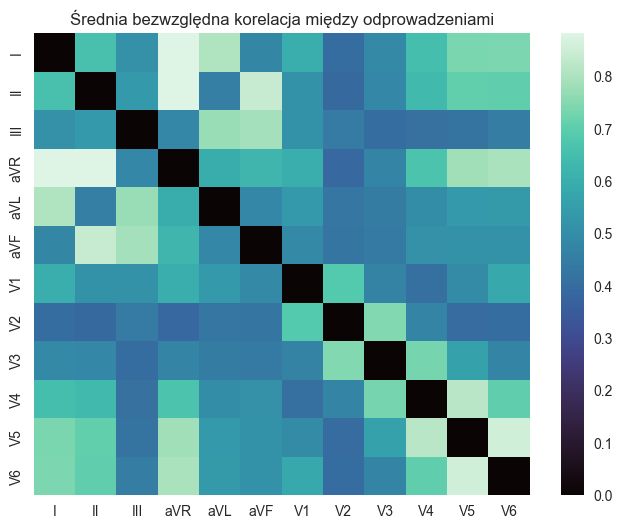

edge_index shape: (2, 64)
number of directed edges: 64


In [ ]:

def build_lead_graph(
    df: pd.DataFrame,
    root: Path,
    sampling_rate: int = 100,
    target_length: int | None = 250,
    max_records: int = 512,
    top_k: int = 4,
):
    subset = df.sample(min(max_records, len(df)), random_state=SEED)
    file_column = "filename_lr" if sampling_rate == 100 else "filename_hr"
    corr_accumulator = np.zeros((12, 12), dtype=np.float64)

    for filename in subset[file_column]:
        signal, _ = wfdb.rdsamp(str(root / filename))
        signal = torch.tensor(signal, dtype=torch.float32).T
        if target_length is not None and signal.shape[1] != target_length:
            signal = F.interpolate(
                signal.unsqueeze(0),
                size=target_length,
                mode="linear",
                align_corners=False,
            ).squeeze(0)
        signal = signal.numpy()
        corr = np.corrcoef(signal)
        corr = np.nan_to_num(np.abs(corr), nan=0.0)
        corr_accumulator += corr

    mean_corr = corr_accumulator / len(subset)
    np.fill_diagonal(mean_corr, 0.0)

    edges = set()
    for source in range(mean_corr.shape[0]):
        neighbors = np.argsort(mean_corr[source])[-top_k:]
        for target in neighbors:
            if source == target:
                continue
            edges.add((source, target))
            edges.add((target, source))

    sorted_edges = sorted(edges)
    edge_index = torch.tensor(sorted_edges, dtype=torch.long).t().contiguous()
    edge_weight = torch.tensor(
        [mean_corr[source, target] for source, target in sorted_edges],
        dtype=torch.float32,
    )
    return mean_corr, edge_index, edge_weight


lead_corr, edge_index, edge_weight = build_lead_graph(
    train_df,
    DATASET_ROOT,
    sampling_rate=SAMPLING_RATE,
    target_length=TARGET_LENGTH,
    max_records=GRAPH_BUILD_SAMPLES,
    top_k=GRAPH_TOP_K,
)

plt.figure(figsize=(8, 6))
sns.heatmap(lead_corr, xticklabels=LEAD_NAMES, yticklabels=LEAD_NAMES, cmap="mako", annot=False)
plt.title("Średnia bezwzględna korelacja między odprowadzeniami")
plt.show()

print("edge_index shape:", tuple(edge_index.shape))
print("number of directed edges:", edge_index.shape[1])


In [7]:

def repeat_graph_for_batch(edge_index, edge_weight, batch_size: int, num_nodes: int, device: torch.device):
    edge_index = edge_index.to(device)
    edge_weight = edge_weight.to(device)
    num_edges = edge_index.shape[1]

    offsets = torch.arange(batch_size, device=device).repeat_interleave(num_edges) * num_nodes
    batch_edge_index = edge_index.repeat(1, batch_size) + offsets
    batch_edge_weight = edge_weight.repeat(batch_size)
    return batch_edge_index, batch_edge_weight


def repeat_graph_for_batch_time(
    edge_index,
    edge_weight,
    batch_size: int,
    num_steps: int,
    num_nodes: int,
    device: torch.device,
):
    return repeat_graph_for_batch(
        edge_index=edge_index,
        edge_weight=edge_weight,
        batch_size=batch_size * num_steps,
        num_nodes=num_nodes,
        device=device,
    )


class CNNAutoencoder(nn.Module):
    def __init__(self, input_channels: int = 12, input_length: int = 250, latent_dim: int = 64):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(input_channels, 32, kernel_size=7, stride=2, padding=3),
            nn.GELU(),
            nn.Conv1d(32, 64, kernel_size=5, stride=2, padding=2),
            nn.GELU(),
            nn.Conv1d(64, 128, kernel_size=5, stride=2, padding=2),
            nn.GELU(),
        )

        with torch.no_grad():
            dummy = torch.zeros(1, input_channels, input_length)
            encoded = self.encoder(dummy)
            self.encoded_shape = encoded.shape[1:]
            flattened = int(np.prod(self.encoded_shape))

        self.to_latent = nn.Sequential(nn.Flatten(), nn.Linear(flattened, latent_dim))
        self.from_latent = nn.Sequential(nn.Linear(latent_dim, flattened), nn.GELU())
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.GELU(),
            nn.ConvTranspose1d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.GELU(),
            nn.ConvTranspose1d(32, input_channels, kernel_size=4, stride=2, padding=1),
        )
        self.input_length = input_length

    def forward(self, x, edge_index=None, edge_weight=None):
        encoded = self.encoder(x)
        latent = self.to_latent(encoded)
        decoded = self.from_latent(latent).view(x.shape[0], *self.encoded_shape)
        reconstruction = self.decoder(decoded)
        if reconstruction.shape[-1] != self.input_length:
            reconstruction = F.interpolate(
                reconstruction,
                size=self.input_length,
                mode="linear",
                align_corners=False,
            )
        return reconstruction, latent


class GCNGRUAutoencoder(nn.Module):
    def __init__(self, num_nodes: int = 12, sequence_length: int = 250, gcn_hidden: int = 32, latent_dim: int = 64):
        super().__init__()
        self.num_nodes = num_nodes
        self.sequence_length = sequence_length
        self.gcn1 = GCNConv(1, gcn_hidden)
        self.gcn2 = GCNConv(gcn_hidden, gcn_hidden)
        self.node_embedding = nn.Embedding(num_nodes, gcn_hidden)
        self.temporal_encoder = nn.GRU(input_size=gcn_hidden, hidden_size=gcn_hidden, batch_first=True)
        self.temporal_norm = nn.LayerNorm(gcn_hidden)
        self.output_head = nn.Sequential(
            nn.Linear(gcn_hidden, gcn_hidden),
            nn.GELU(),
            nn.Linear(gcn_hidden, 1),
        )
        self.to_latent = nn.Linear(gcn_hidden, latent_dim)

    def forward(self, x, edge_index, edge_weight=None):
        batch_size, num_nodes, sequence_length = x.shape
        batch_edge_index, batch_edge_weight = repeat_graph_for_batch_time(
            edge_index=edge_index,
            edge_weight=edge_weight,
            batch_size=batch_size,
            num_steps=sequence_length,
            num_nodes=num_nodes,
            device=x.device,
        )

        graph_inputs = x.permute(0, 2, 1).reshape(batch_size * sequence_length * num_nodes, 1)
        h = self.gcn1(graph_inputs, batch_edge_index, batch_edge_weight)
        h = F.gelu(h)
        h = self.gcn2(h, batch_edge_index, batch_edge_weight)
        h = F.gelu(h)
        h = h.view(batch_size, sequence_length, num_nodes, -1).permute(0, 2, 1, 3)

        node_bias = self.node_embedding(torch.arange(num_nodes, device=x.device)).view(1, num_nodes, 1, -1)
        h = h + node_bias
        h = h.reshape(batch_size * num_nodes, sequence_length, -1)

        encoded_sequence, hidden = self.temporal_encoder(h)
        encoded_sequence = self.temporal_norm(encoded_sequence)

        reconstruction = self.output_head(encoded_sequence.reshape(batch_size * num_nodes * sequence_length, -1))
        reconstruction = reconstruction.view(batch_size, num_nodes, sequence_length)

        latent = self.to_latent(hidden[-1]).view(batch_size, num_nodes * self.to_latent.out_features)
        return reconstruction, latent


class GConvGRUAutoencoder(nn.Module):
    def __init__(self, num_nodes: int = 12, sequence_length: int = 250, gcn_hidden: int = 32, latent_dim: int = 64):
        super().__init__()
        self.num_nodes = num_nodes
        self.sequence_length = sequence_length
        self.temporal_encoder = nn.Sequential(
            nn.Conv1d(1, 8, kernel_size=7, stride=2, padding=3),
            nn.GELU(),
        )
        self.recurrent = GConvGRU(in_channels=8, out_channels=gcn_hidden, K=2)
        self.node_embedding = nn.Embedding(num_nodes, gcn_hidden)
        self.temporal_decoder = nn.Sequential(
            nn.Conv1d(gcn_hidden, gcn_hidden, kernel_size=5, padding=2),
            nn.GELU(),
            nn.ConvTranspose1d(gcn_hidden, 16, kernel_size=4, stride=2, padding=1),
            nn.GELU(),
            nn.Conv1d(16, 1, kernel_size=5, padding=2),
        )
        self.to_latent = nn.Linear(gcn_hidden, latent_dim)

    def forward(self, x, edge_index, edge_weight=None):
        batch_size, num_nodes, sequence_length = x.shape
        encoded = self.temporal_encoder(x.reshape(batch_size * num_nodes, 1, sequence_length))
        compressed_length = encoded.shape[-1]
        encoded = encoded.view(batch_size, num_nodes, -1, compressed_length).permute(0, 1, 3, 2)

        batch_edge_index, batch_edge_weight = repeat_graph_for_batch(
            edge_index=edge_index,
            edge_weight=edge_weight,
            batch_size=batch_size,
            num_nodes=num_nodes,
            device=x.device,
        )

        hidden = None
        hidden_states = []
        node_bias = self.node_embedding(torch.arange(num_nodes, device=x.device)).repeat(batch_size, 1)

        for t in range(compressed_length):
            x_t = encoded[:, :, t, :].reshape(batch_size * num_nodes, -1)
            hidden = self.recurrent(x_t, batch_edge_index, edge_weight=batch_edge_weight, H=hidden)
            hidden_states.append(hidden + node_bias)

        hidden_sequence = torch.stack(hidden_states, dim=1)
        decoder_input = hidden_sequence.permute(0, 2, 1)
        reconstruction = self.temporal_decoder(decoder_input).squeeze(1).view(batch_size, num_nodes, -1)

        if reconstruction.shape[-1] != sequence_length:
            reconstruction = F.interpolate(
                reconstruction,
                size=sequence_length,
                mode="linear",
                align_corners=False,
            )

        pooled_hidden = hidden_sequence.mean(dim=1).view(batch_size, num_nodes, -1)
        latent = self.to_latent(pooled_hidden).reshape(batch_size, num_nodes * self.to_latent.out_features)
        return reconstruction, latent


In [8]:

def train_autoencoder(model, train_loader, val_loader, edge_index, edge_weight, training_config=None, model_name="model"):
    config = {**DEFAULT_TRAINING_CONFIG, **(training_config or {})}
    max_epochs = config["max_epochs"]
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=config["lr"],
        weight_decay=WEIGHT_DECAY,
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=config["scheduler_factor"],
        patience=config["scheduler_patience"],
        min_lr=config["min_lr"],
    )
    criterion = nn.MSELoss()
    history = []
    best_state = None
    best_val_loss = float("inf")
    best_epoch = 0
    epochs_without_improvement = 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        train_losses = []
        for signals, _, _ in train_loader:
            signals = signals.to(DEVICE)
            optimizer.zero_grad()
            reconstructions, _ = model(signals, edge_index=edge_index, edge_weight=edge_weight)
            loss = criterion(reconstructions, signals)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            for signals, _, _ in val_loader:
                signals = signals.to(DEVICE)
                reconstructions, _ = model(signals, edge_index=edge_index, edge_weight=edge_weight)
                loss = criterion(reconstructions, signals)
                val_losses.append(loss.item())

        epoch_train = float(np.mean(train_losses))
        epoch_val = float(np.mean(val_losses))
        current_lr = float(optimizer.param_groups[0]["lr"])
        scheduler.step(epoch_val)

        improved = epoch_val < best_val_loss - 1e-5
        if improved:
            best_val_loss = epoch_val
            best_epoch = epoch
            epochs_without_improvement = 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            epochs_without_improvement += 1

        history.append(
            {
                "epoch": epoch,
                "train_loss": epoch_train,
                "val_loss": epoch_val,
                "lr": current_lr,
                "best_val_loss_so_far": best_val_loss,
            }
        )
        print(
            f"{model_name:>16} | epoch {epoch:02d}/{max_epochs} | "
            f"train={epoch_train:.4f} | val={epoch_val:.4f} | lr={current_lr:.2e}"
        )

        if epochs_without_improvement >= config["early_stopping_patience"]:
            print(
                f"{model_name:>16} | early stopping po epoce {epoch:02d} "
                f"(best epoch: {best_epoch:02d}, best val={best_val_loss:.4f})"
            )
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    history_df = pd.DataFrame(history)
    history_df.attrs["best_epoch"] = best_epoch
    history_df.attrs["best_val_loss"] = best_val_loss
    history_df.attrs["trained_epochs"] = len(history_df)
    history_df.attrs["training_config"] = config
    return history_df


@torch.no_grad()
def collect_outputs(model, loader, edge_index, edge_weight):
    model.eval()
    originals = []
    reconstructions = []
    latents = []
    labels = []
    ecg_ids = []

    for signals, batch_labels, batch_ids in loader:
        signals = signals.to(DEVICE)
        reconstructed, latent = model(signals, edge_index=edge_index, edge_weight=edge_weight)
        originals.append(signals.cpu().numpy())
        reconstructions.append(reconstructed.cpu().numpy())
        latents.append(latent.cpu().numpy())
        labels.extend(list(batch_labels))
        ecg_ids.extend(batch_ids.tolist())

    return {
        "originals": np.concatenate(originals, axis=0),
        "reconstructions": np.concatenate(reconstructions, axis=0),
        "latents": np.concatenate(latents, axis=0),
        "labels": np.array(labels),
        "ecg_ids": np.array(ecg_ids),
    }


def compute_metrics(outputs):
    y_true = outputs["originals"]
    y_pred = outputs["reconstructions"]
    mse = float(np.mean((y_true - y_pred) ** 2))
    mae = float(np.mean(np.abs(y_true - y_pred)))
    return {"mse": mse, "mae": mae}


def zero_baseline_metrics(loader):
    zeros = []
    signals_all = []
    for signals, _, _ in loader:
        signals_all.append(signals.numpy())
        zeros.append(np.zeros_like(signals.numpy()))
    y_true = np.concatenate(signals_all, axis=0)
    y_pred = np.concatenate(zeros, axis=0)
    return {
        "model": "Zero baseline",
        "mse": float(np.mean((y_true - y_pred) ** 2)),
        "mae": float(np.mean(np.abs(y_true - y_pred))),
        "best_val_loss": np.nan,
        "best_epoch": np.nan,
        "trained_epochs": np.nan,
    }


In [9]:

model_factories = {
    "CNN Autoencoder": lambda: CNNAutoencoder(
        input_channels=12,
        input_length=TARGET_LENGTH,
        latent_dim=LATENT_DIM,
    ).to(DEVICE),
    "GCN-GRU": lambda: GCNGRUAutoencoder(
        num_nodes=12,
        sequence_length=TARGET_LENGTH,
        gcn_hidden=GCN_HIDDEN,
        latent_dim=LATENT_DIM,
    ).to(DEVICE),
    "GConvGRU": lambda: GConvGRUAutoencoder(
        num_nodes=12,
        sequence_length=TARGET_LENGTH,
        gcn_hidden=GCN_HIDDEN,
        latent_dim=LATENT_DIM,
    ).to(DEVICE)
}

training_plan_df = pd.DataFrame.from_dict(MODEL_TRAINING_CONFIG, orient="index").reset_index(names="model")
display(training_plan_df)

trained_models = {}
histories = {}
outputs_by_model = {}
metrics_rows = [zero_baseline_metrics(test_loader)]

for model_name, factory in model_factories.items():
    print(f"Training: {model_name}")
    model = factory()
    training_config = MODEL_TRAINING_CONFIG.get(model_name, DEFAULT_TRAINING_CONFIG)
    history = train_autoencoder(
        model,
        train_loader,
        val_loader,
        edge_index=edge_index,
        edge_weight=edge_weight,
        training_config=training_config,
        model_name=model_name,
    )
    outputs = collect_outputs(model, test_loader, edge_index=edge_index, edge_weight=edge_weight)
    metrics = compute_metrics(outputs)

    trained_models[model_name] = model
    histories[model_name] = history
    outputs_by_model[model_name] = outputs
    metrics_rows.append(
        {
            "model": model_name,
            **metrics,
            "best_val_loss": history.attrs["best_val_loss"],
            "best_epoch": history.attrs["best_epoch"],
            "trained_epochs": history.attrs["trained_epochs"],
        }
    )

metrics_df = pd.DataFrame(metrics_rows).sort_values("mse").reset_index(drop=True)
display(metrics_df)


,model,max_epochs,lr,early_stopping_patience,scheduler_patience,scheduler_factor,min_lr
0,CNN Autoencoder,50,0.001,4,3,0.5,0.00001
1,GCN-GRU,30,0.001,3,2,0.5,0.00001
2,GConvGRU,10,0.001,3,3,0.5,0.00001


Training: CNN Autoencoder
 CNN Autoencoder | epoch 01/50 | train=0.9620 | val=0.9059 | lr=1.00e-03
 CNN Autoencoder | epoch 02/50 | train=0.8192 | val=0.7146 | lr=1.00e-03
 CNN Autoencoder | epoch 03/50 | train=0.6467 | val=0.5947 | lr=1.00e-03
 CNN Autoencoder | epoch 04/50 | train=0.5539 | val=0.5538 | lr=1.00e-03
 CNN Autoencoder | epoch 05/50 | train=0.5206 | val=0.5325 | lr=1.00e-03
 CNN Autoencoder | epoch 06/50 | train=0.4994 | val=0.5196 | lr=1.00e-03
 CNN Autoencoder | epoch 07/50 | train=0.4799 | val=0.4927 | lr=1.00e-03
 CNN Autoencoder | epoch 08/50 | train=0.4472 | val=0.4617 | lr=1.00e-03
 CNN Autoencoder | epoch 09/50 | train=0.4206 | val=0.4454 | lr=1.00e-03
 CNN Autoencoder | epoch 10/50 | train=0.4036 | val=0.4364 | lr=1.00e-03
 CNN Autoencoder | epoch 11/50 | train=0.3874 | val=0.4212 | lr=1.00e-03
 CNN Autoencoder | epoch 12/50 | train=0.3743 | val=0.4113 | lr=1.00e-03
 CNN Autoencoder | epoch 13/50 | train=0.3615 | val=0.4043 | lr=1.00e-03
 CNN Autoencoder | epoch 

,model,mse,mae,best_val_loss,best_epoch,trained_epochs
0,GConvGRU,0.004602,0.031487,0.003936,9.0,10.0
1,GCN-GRU,0.230515,0.301538,0.237799,30.0,30.0
2,CNN Autoencoder,0.353147,0.395481,0.358947,33.0,37.0
3,Zero baseline,0.996000,0.634308,NaN,NaN,NaN


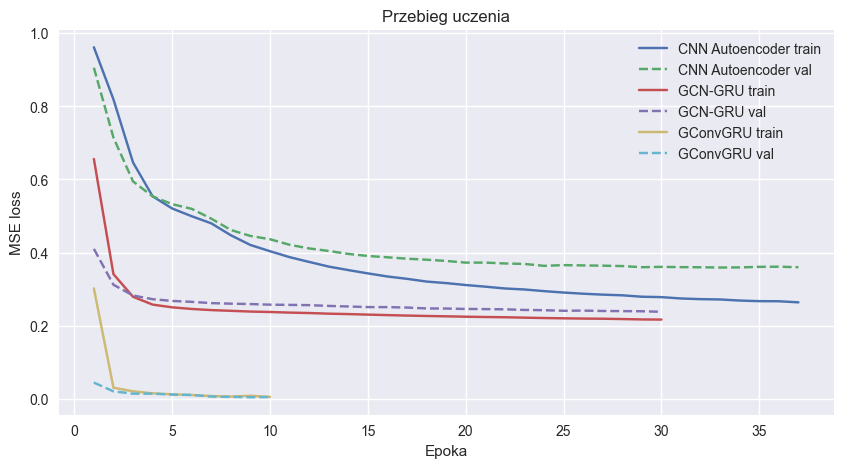

In [10]:

plt.figure(figsize=(10, 5))
for model_name, history in histories.items():
    plt.plot(history["epoch"], history["train_loss"], label=f"{model_name} train")
    plt.plot(history["epoch"], history["val_loss"], linestyle="--", label=f"{model_name} val")

plt.xlabel("Epoka")
plt.ylabel("MSE loss")
plt.title("Przebieg uczenia")
plt.legend()
plt.show()


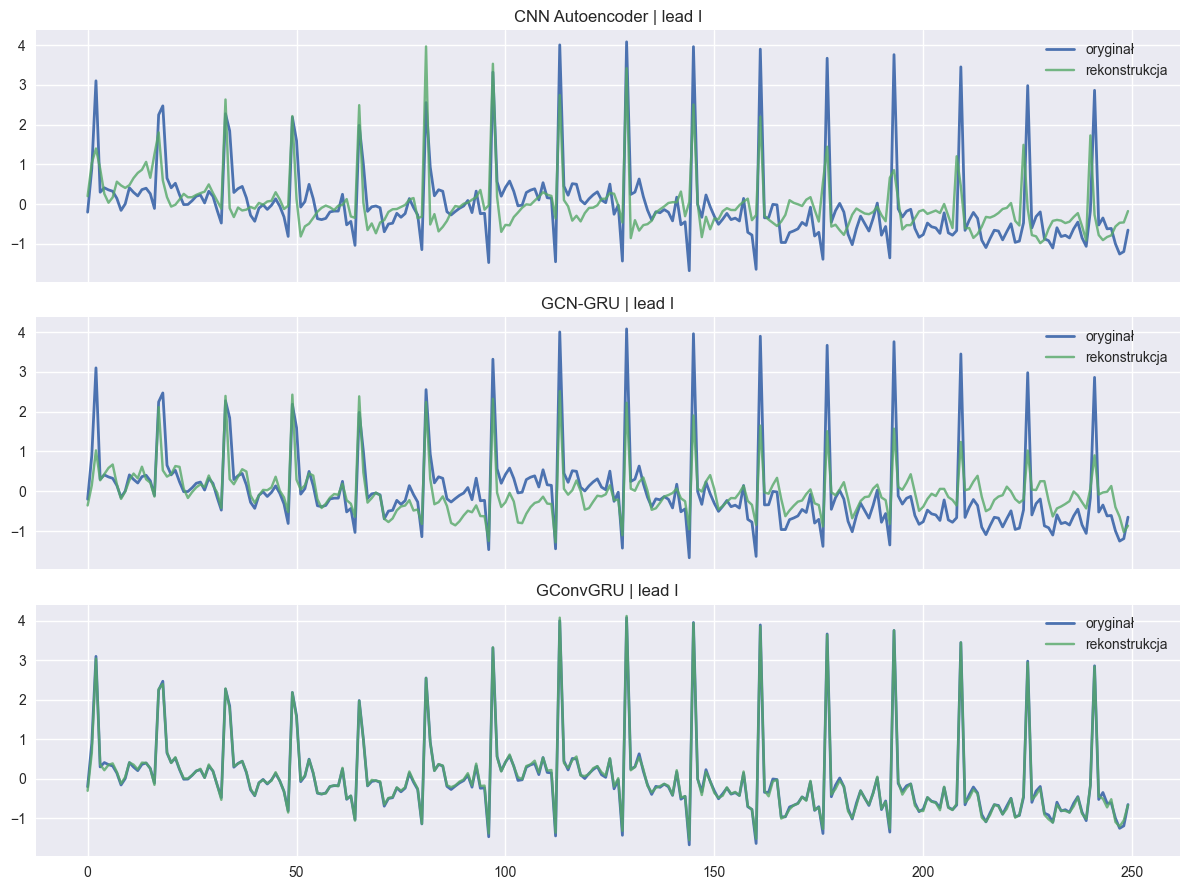

In [11]:

def plot_reconstruction_examples(outputs_by_model, sample_index: int = 0, lead_idx: int = 0):
    num_models = len(outputs_by_model)
    fig, axes = plt.subplots(num_models, 1, figsize=(12, 3 * num_models), sharex=True)
    if num_models == 1:
        axes = [axes]

    for ax, (model_name, outputs) in zip(axes, outputs_by_model.items()):
        original = outputs["originals"][sample_index, lead_idx]
        reconstruction = outputs["reconstructions"][sample_index, lead_idx]
        ax.plot(original, label="oryginał", linewidth=2)
        ax.plot(reconstruction, label="rekonstrukcja", alpha=0.8)
        ax.set_title(f"{model_name} | lead {LEAD_NAMES[lead_idx]}")
        ax.legend()

    plt.tight_layout()
    plt.show()


plot_reconstruction_examples(outputs_by_model, sample_index=0, lead_idx=0)


In [ ]:

def reduce_embeddings(latents: np.ndarray, method: str = "umap", random_state: int = 42):
    if method == "umap":
        reducer = umap.UMAP(
            n_neighbors=20,
            min_dist=0.15,
            metric="euclidean",
            random_state=random_state,
        )
    elif method == "tsne":
        perplexity = min(30, max(5, latents.shape[0] // 20))
        reducer = TSNE(
            n_components=2,
            perplexity=perplexity,
            init="pca",
            learning_rate="auto",
            random_state=random_state,
        )
    else:
        raise ValueError("method must be 'umap' or 'tsne'")

    return reducer.fit_transform(latents)


def plot_embedding_grid(outputs_by_model, method: str = "umap", max_points: int = 800):
    num_models = len(outputs_by_model)
    fig, axes = plt.subplots(num_models, 1, figsize=(10, 5 * num_models))
    if num_models == 1:
        axes = [axes]

    rng = np.random.default_rng(SEED)

    for ax, (model_name, outputs) in zip(axes, outputs_by_model.items()):
        latents = outputs["latents"]
        labels = outputs["labels"]

        if len(latents) > max_points:
            indices = rng.choice(len(latents), size=max_points, replace=False)
            latents = latents[indices]
            labels = labels[indices]

        projection = reduce_embeddings(latents, method=method, random_state=SEED)
        label_counts = pd.Series(labels).value_counts()
        top_labels = set(label_counts.head(6).index)
        compact_labels = np.array([label if label in top_labels else "OTHER" for label in labels])

        for label in sorted(np.unique(compact_labels)):
            mask = compact_labels == label
            ax.scatter(
                projection[mask, 0],
                projection[mask, 1],
                s=16,
                alpha=0.75,
                label=label,
            )

        ax.set_title(f"{model_name} - {method.upper()}")
        ax.set_xlabel("dim 1")
        ax.set_ylabel("dim 2")
        ax.legend(loc="best", fontsize=8)

    plt.tight_layout()
    plt.show()


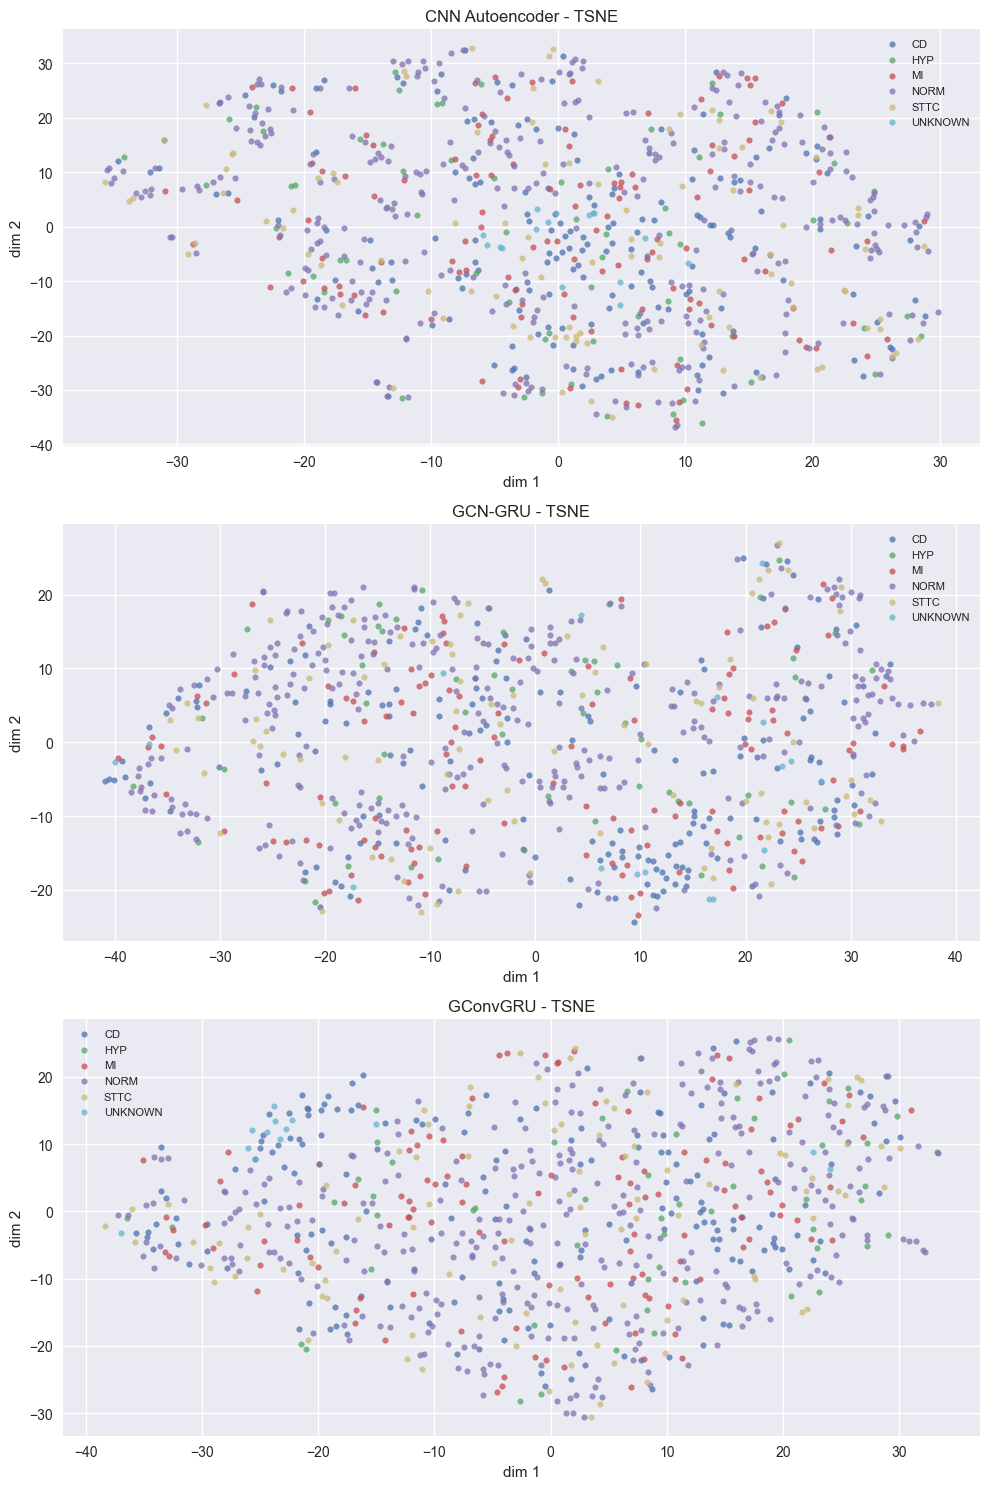

c:\Users\piotr\.pyenv\pyenv-win\versions\3.11.8\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\piotr\.pyenv\pyenv-win\versions\3.11.8\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\piotr\.pyenv\pyenv-win\versions\3.11.8\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


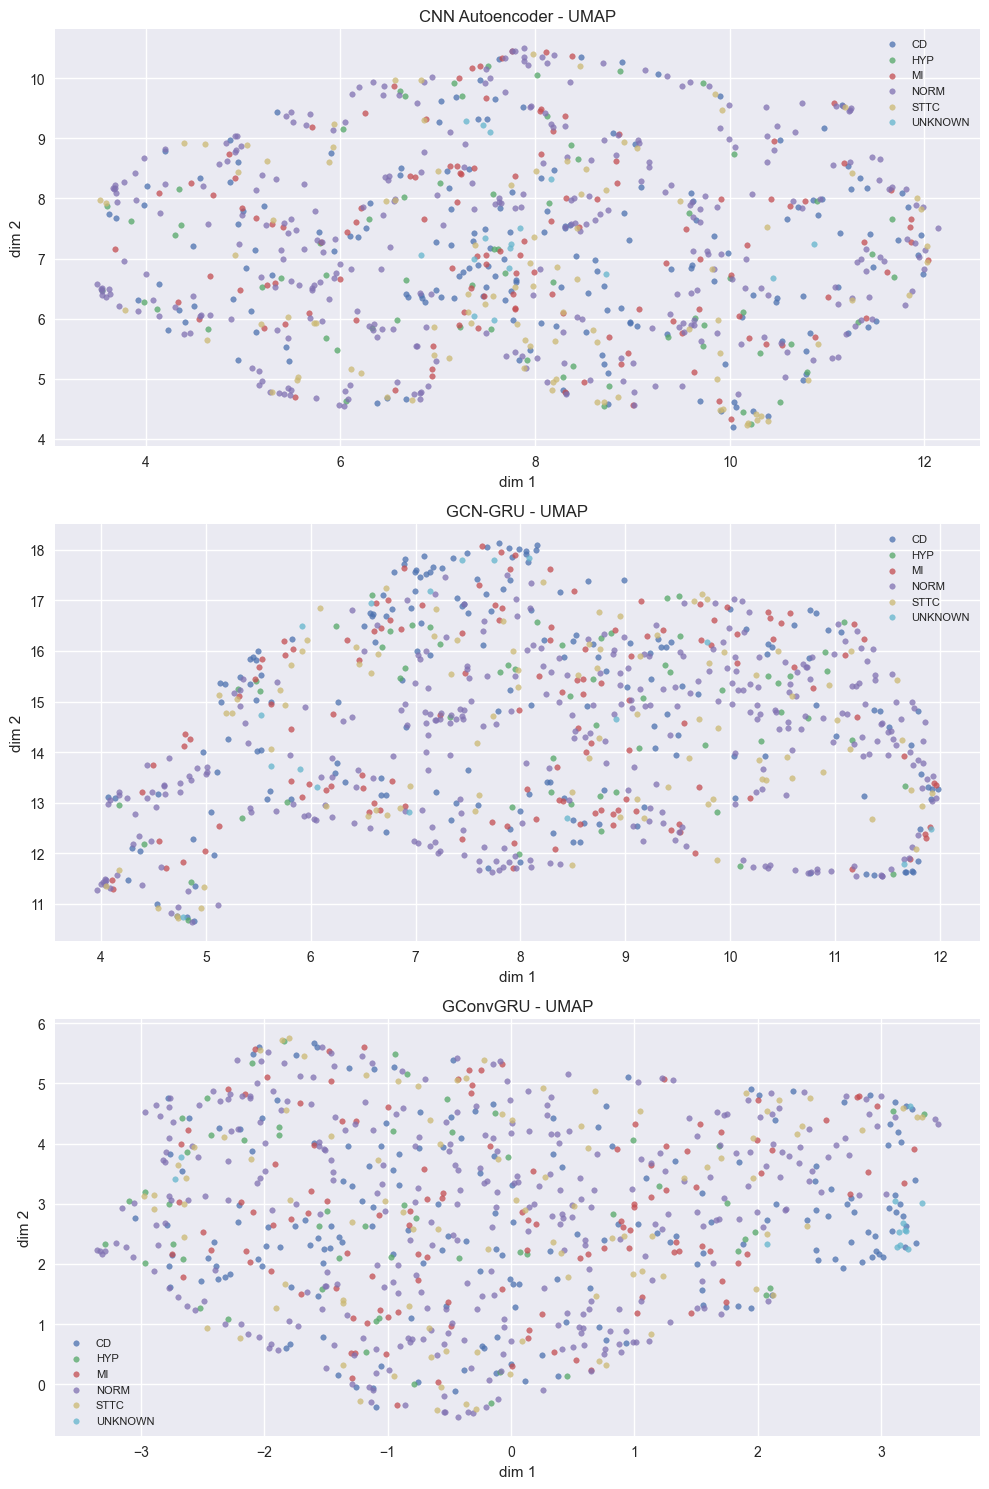

In [14]:

plot_embedding_grid(outputs_by_model, method="tsne")
plot_embedding_grid(outputs_by_model, method="umap")
